# EDA — Macrobús · datos para el modelo de RL de despacho

Explora el dump de la BD `integration` (jul–sep 2026) con foco en **horarios de salida
de las unidades**.

Los ayudantes viven en `src/`. Este notebook se genera desde `scripts/build_eda.py`.

---

## Resumen ejecutivo

**1. La oferta es casi plana, la demanda no, y entre ellas no hay relación.** En la franja
plenamente operativa (06–20 h de día hábil) la troncal despacha con una razón pico/valle de
**1.25**, mientras la demanda varía con razón **1.90** y picos gemelos a las 07 h y 18 h. La
correlación entre ambas curvas es **−0.03**: prácticamente nula. El operador despacha a
intervalo constante sin seguir la demanda. Ahí está el margen del agente.

**2. Dos relojes distintos en la misma base.** `in_device_history_location.time` es
`TIMESTAMP` y está en **UTC**; `transaction_*.fechaHoraEvento` es `DATETIME` y está en
**hora local**. Cruzarlas sin ajustar corre el análisis 6 horas.

**3. Los identificadores no son lo que dicen.** El `id_bus` del GPS viene corrido +10 000
respecto de `bus.id_bus`, y el `id_route` del GPS es en realidad `route.id_ruta_estacion`.
Un join ingenuo devuelve **cero filas sin marcar error**.

**4. No hay tabla de despachos.** La hora de salida se infiere del GPS. El método de este
notebook detecta **32 616 salidas** en dos meses, con recorrido mediano de **42.3 min**.

**5. Falta el dato que cierra la recompensa.** Ninguna de las 303 columnas guarda capacidad
ni costo por unidad.

## 0. Setup

In [1]:
import sys, warnings
from pathlib import Path

sys.path.insert(0, str(Path.cwd() / "src"))
warnings.filterwarnings("ignore")

import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

import db, fleet, departures as dp, demand

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 50)

plt.rcParams.update({
    "figure.figsize": (11, 4), "figure.dpi": 110,
    "axes.grid": True, "grid.alpha": .25, "axes.spines.top": False,
    "axes.spines.right": False, "font.size": 10,
})
AZUL, NARANJA, GRIS = "#2b6cb0", "#dd6b20", "#a0aec0"

# Franja plenamente operativa. El servicio corre de 05 h a 22 h, pero 05 h y 21–22 h son
# horas de arranque y cierre: ahí oferta y demanda suben y bajan juntas por construcción,
# lo que infla artificialmente cualquier razón pico/valle y cualquier correlación.
# Todas las comparaciones oferta–demanda de este notebook usan esta ventana.
CORE_H = list(range(6, 21))  # 06:00 – 20:59

print("conectado:", f"{db.scalar('SELECT COUNT(*) FROM in_device_history_location'):,}", "pings GPS")

conectado: 19,156,273 pings GPS


## 1. Inventario y cobertura

Qué hay y de cuándo. Antes de cualquier análisis conviene saber si la ventana temporal es
continua o tiene huecos de captura.

In [2]:
SQL_INV = '''
    SELECT 'GPS' AS tabla, COUNT(*) n, MIN(time) desde, MAX(time) hasta
      FROM in_device_history_location
    UNION ALL SELECT 'AFC troncal T1', COUNT(*), MIN(fechaHoraEvento), MAX(fechaHoraEvento)
      FROM transaction_1
    UNION ALL SELECT 'AFC ruta T01', COUNT(*), MIN(fechaHoraEvento), MAX(fechaHoraEvento)
      FROM transaction_5
    UNION ALL SELECT 'Agregado diario', COUNT(*), MIN(date), MAX(date)
      FROM afc_bus_total
'''
inv = db.q(SQL_INV, cache="inventario")
inv["n"] = inv["n"].map("{:,}".format)
inv

,tabla,n,desde,hasta
0,GPS,"19,156,273",2026-07-03 06:00:00,2026-09-02 23:17:04
1,AFC troncal T1,"7,441,313",2026-07-01 04:01:20,2026-09-02 17:15:18
2,AFC ruta T01,"903,121",2026-07-01 04:40:46,2026-09-02 17:12:10
3,Agregado diario,"12,711",2026-07-01 00:00:00,2026-09-01 00:00:00


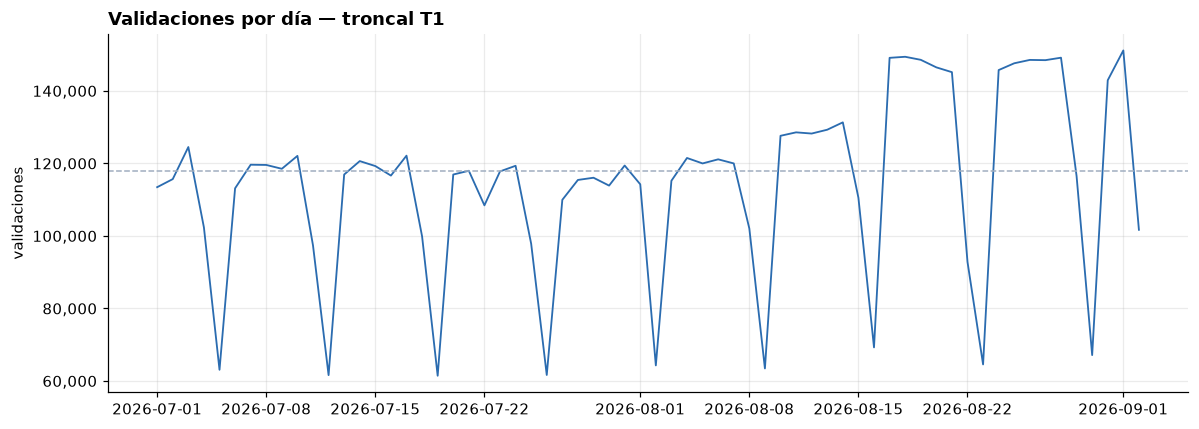

días con datos : 64
rango          : 2026-07-01 .. 2026-09-02
días faltantes : 0 


In [3]:
serie = demand.demanda_por_dia()
serie["fecha"] = pd.to_datetime(serie["fecha"])

fig, ax = plt.subplots()
ax.plot(serie["fecha"], serie["validaciones"], color=AZUL, lw=1.2)
ax.axhline(serie["validaciones"].median(), color=GRIS, ls="--", lw=1)
ax.set_title("Validaciones por día — troncal T1", loc="left", weight="bold")
ax.set_ylabel("validaciones")
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))
plt.tight_layout(); plt.show()

faltan = pd.date_range(serie.fecha.min(), serie.fecha.max()).difference(serie.fecha)
print(f"días con datos : {len(serie)}")
print(f"rango          : {serie.fecha.min():%Y-%m-%d} .. {serie.fecha.max():%Y-%m-%d}")
print(f"días faltantes : {len(faltan)}", [str(d.date()) for d in faltan] or "")

El dentado regular es el ciclo semanal: los domingos caen a cerca de la mitad. No hay
huecos de captura, así que la ventana sirve completa para entrenar.

## 2. Identidad — el join que rompe en silencio

Este es el hallazgo que más tiempo ahorra. Las llaves entre el GPS y el catálogo de
unidades **no coinciden por nombre**, y un `JOIN` directo no falla: devuelve vacío.

In [4]:
SQL_INGENUO = '''
    SELECT COUNT(*) AS filas_que_resuelven
    FROM in_device_history_location g JOIN bus b ON b.id_bus = g.id_bus
'''
print("Join ingenuo  gps.id_bus = bus.id_bus:")
print(db.q(SQL_INGENUO).to_string(index=False))

print()
print("Corrigiendo los dos esquemas de identidad:")
print(fleet.cobertura_identidad().to_string(index=False))

Join ingenuo  gps.id_bus = bus.id_bus:


 filas_que_resuelven
                  12

Corrigiendo los dos esquemas de identidad:
             mecanismo    filas  huerfanas
id_ebjdevice -> id_oct  3144954        0.0
        id_bus - 10000 16011319       13.0


Las tres reglas, verificadas sobre el dump del 2026-09-02:

| Campo del GPS | Qué parece | Qué es realmente |
|---|---|---|
| `id_route` | `route.id_route` | `route.id_ruta_estacion` — la troncal es `79001001`, no `2` |
| `id_bus` (≠ 0) | `bus.id_bus` | `bus.id_bus + 10000` |
| `id_bus` = 0 | dato faltante | ruta T01; el enlace real es `id_ebjdevice` → **`bus.id_oct`** |

Ojo con la tercera: **no** es `bus.id_ebjdevice`, pese al nombre. Esa columna está marcada
como *campo en desuso* en el diccionario y no empata.

Cobertura final: 19 156 260 de 19 156 273 pings quedan atribuidos a una unidad concreta.

## 3. Zonas horarias — dos relojes en la misma base

Segundo hallazgo que invalida análisis si se pasa por alto.

In [5]:
SQL_TIPOS = '''
    SELECT TABLE_NAME AS tabla, COLUMN_NAME AS columna, DATA_TYPE AS tipo
    FROM information_schema.COLUMNS
    WHERE TABLE_SCHEMA = 'integration'
      AND COLUMN_NAME IN ('time','fechaHoraEvento')
      AND TABLE_NAME IN ('in_device_history_location','transaction_1')
'''
print(db.q(SQL_TIPOS).to_string(index=False))

print()
print("El GPS trae dev_date/dev_time, la hora local que reporta el equipo:")
print(db.q("SELECT time AS time_utc, dev_date, dev_time "
           "FROM in_device_history_location LIMIT 3").to_string(index=False))

                     tabla         columna      tipo
in_device_history_location            time timestamp
             transaction_1 fechaHoraEvento  datetime

El GPS trae dev_date/dev_time, la hora local que reporta el equipo:
           time_utc dev_date dev_time
2026-07-03 06:00:00   020726   235958
2026-07-03 06:00:00   020726   235959
2026-07-03 06:00:00   020726   235958


`time` marca 06:00:00 mientras el equipo reporta 23:59:58 del día anterior: **6 horas
exactas**, el offset de Guadalajara.

La causa es la semántica de MySQL. `TIMESTAMP` se normaliza a UTC al guardar; `DATETIME`
se guarda literal. Como el dump se tomó con `TIME_ZONE='+00:00'`, las columnas `TIMESTAMP`
salieron en UTC y las `DATETIME` conservaron la hora local.

**Consecuencia práctica:** al GPS hay que restarle 6 h, a las validaciones AFC **no**.
`src/departures.py` convierte; `src/demand.py` deliberadamente no.

## 4. Flota

In [6]:
cat = fleet.catalogo_unidades()
print(f"unidades en catálogo: {len(cat)}   ·   activas: {(cat.status == 1).sum()}")
display(cat.groupby(["ruta", "brand"]).size().unstack(fill_value=0))
print("modelo (sin catálogo que lo explique):")
print(cat.groupby(["ruta", "model"]).size().unstack(fill_value=0).to_string())

unidades en catálogo: 229   ·   activas: 182


brand,DEF,Dina,International,Mercedes Benz
ruta,,,,
Alimentadoras,125,0,0,0
Macrobus T1,76,0,0,0
T01,1,9,1,17


modelo (sin catálogo que lo explique):
model           1    2
ruta                  
Alimentadoras   0  125
Macrobus T1     0   76
T01            25    3


`model` toma los valores `'1'` y `'2'` sin catálogo que los explique, y `brand` distingue
Dina / Mercedes Benz / International. **Ninguna columna guarda capacidad ni costo**, que es
justo lo que la recompensa necesita. Ver §7.

## 5. Horarios de salida

No hay tabla de despachos: la salida se **infiere** del GPS.

**Método.** Se traza un círculo de 250 m alrededor de cada terminal. Una *salida* es el
último ping dentro de una zona antes de que la unidad desaparezca de toda zona terminal por
20 min o más; el siguiente ping en zona es la *llegada*. Sólo requiere los pings dentro de
las zonas (~17 % del total) y no depende de umbrales de velocidad ni de suavizado.

In [7]:
term = dp.terminales(2)
sur = term[term.name.str.contains("START")].iloc[0]
norte = term[term.name.str.contains("END")].iloc[0]
display(term)

pings = dp.pings_en_terminal(fleet.TRONCAL_T1, sur.latitude, sur.longitude,
                             norte.latitude, norte.longitude)
sal = dp.detectar_salidas(pings)

print(f"pings en zona terminal : {len(pings):,}")
print(f"salidas detectadas     : {len(sal):,}")
print(f"unidades distintas     : {sal.id_bus.nunique()}")
print()
print("distribución por zona:")
print(pings.zona.value_counts().to_string())
print()
print("recorrido (min):")
print(sal.recorrido_min.describe().round(1).to_string())

,name,latitude,longitude
0,Terminal_END,20.739557,-103.311496
1,Terminal_START,20.606400,-103.343666


pings en zona terminal : 1,066,269
salidas detectadas     : 32,616
unidades distintas     : 61

distribución por zona:
zona
SUR      936293
NORTE    129976

recorrido (min):
count    32616.0
mean        45.7
std         17.7
min         20.0
25%         36.7
50%         42.3
75%         47.7
max        179.8


La asimetría entre zonas es informativa: **936 293 pings en la terminal sur contra 129 976
en la norte**. El sur es donde las unidades hacen base entre vueltas; la norte es sólo
retorno. Para el modelo, el sur es el punto de despacho.

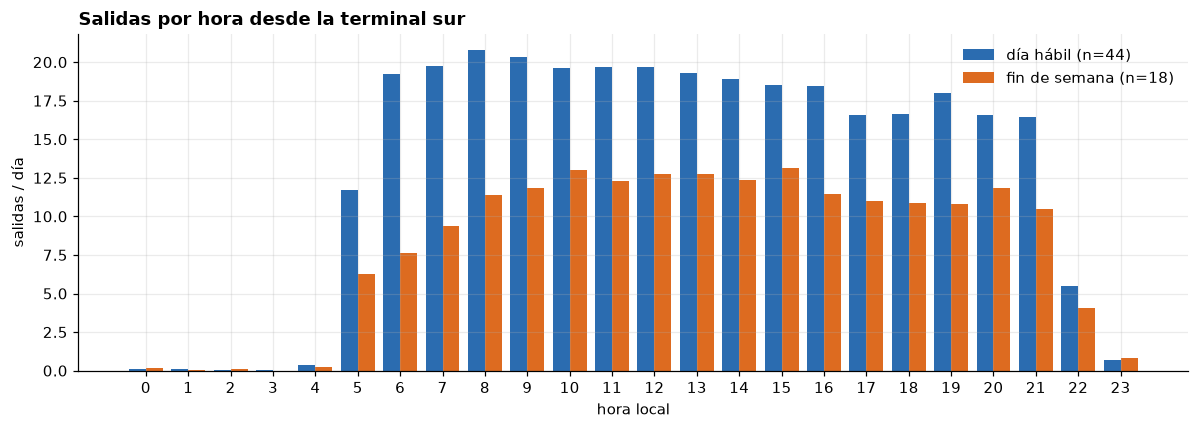

ventana de servicio : 05:00 – 22:00 local
franja núcleo       : 06:00 – 20:59

pico  : 20.8 salidas/h a las 08:00
valle : 16.6 salidas/h a las 17:00
razón pico/valle en la franja núcleo: 1.25
(incluyendo arranque y cierre subiría a 3.81, que mide el horario, no la respuesta a la demanda)


In [8]:
hab, fin = sal[~sal.finde], sal[sal.finde]
n_hab, n_fin = hab.fecha.nunique(), fin.fecha.nunique()

perfil = pd.DataFrame({
    "hábil": hab[hab.desde == "SUR"].groupby("hora").size() / n_hab,
    "finde": fin[fin.desde == "SUR"].groupby("hora").size() / n_fin,
}).reindex(range(24)).fillna(0)

fig, ax = plt.subplots()
ax.bar(perfil.index - .2, perfil["hábil"], .4, label=f"día hábil (n={n_hab})", color=AZUL)
ax.bar(perfil.index + .2, perfil["finde"], .4, label=f"fin de semana (n={n_fin})", color=NARANJA)
ax.set_title("Salidas por hora desde la terminal sur", loc="left", weight="bold")
ax.set_xlabel("hora local"); ax.set_ylabel("salidas / día"); ax.set_xticks(range(24))
ax.legend(frameon=False); plt.tight_layout(); plt.show()

serv = perfil[perfil["hábil"] > 1]["hábil"]
core = perfil.loc[CORE_H, "hábil"]
print(f"ventana de servicio : {serv.index.min():02d}:00 – {serv.index.max():02d}:00 local")
print(f"franja núcleo       : {CORE_H[0]:02d}:00 – {CORE_H[-1]:02d}:59")
print()
print(f"pico  : {core.max():.1f} salidas/h a las {core.idxmax():02d}:00")
print(f"valle : {core.min():.1f} salidas/h a las {core.idxmin():02d}:00")
print(f"razón pico/valle en la franja núcleo: {core.max() / core.min():.2f}")
print(f"(incluyendo arranque y cierre subiría a {serv.max() / serv.min():.2f}, "
      "que mide el horario, no la respuesta a la demanda)")

El perfil de oferta es **notablemente plano**: una meseta de ~20 salidas/hora desde las 06 h
hasta media tarde, con un descenso suave al anochecer. No hay refuerzo de hora pico.

Los fines de semana operan a ~60 % del servicio, con la misma forma achatada.

Nótese la diferencia entre las dos razones que imprime la celda. Medida sobre toda la
ventana de servicio, la oferta parece variar bastante (3.8×), pero eso sólo refleja que el
servicio abre y cierra. Dentro de la franja núcleo la variación real es de 1.25×.

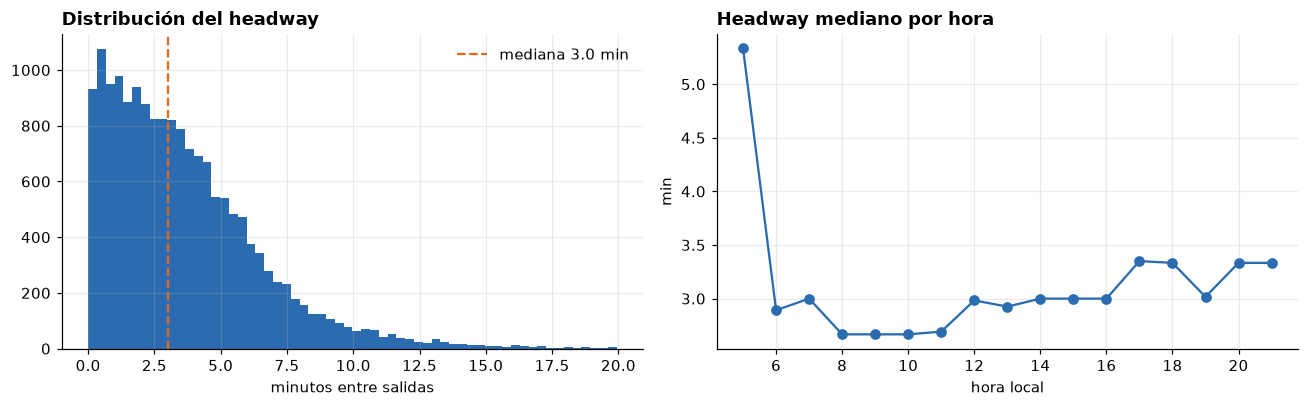

      count  median  mean   std
hora                           
5       591     5.3   8.4  23.9
6       984     2.9   3.8   3.8
7      1039     3.0   3.6   3.4
8      1119     2.7   3.3   3.1
9      1108     2.7   3.3   2.8
10     1098     2.7   3.4   2.9
11     1086     2.7   3.4   2.9
12     1094     3.0   3.4   2.7
13     1080     2.9   3.4   2.7
14     1055     3.0   3.5   2.8
15     1052     3.0   3.5   3.3
16     1017     3.0   3.6   3.2
17      927     3.4   3.7   2.7
18      927     3.3   3.9   4.9
19      988     3.0   3.6   2.9
20      942     3.3   3.7   2.9
21      913     3.3   4.1   9.6


In [9]:
hw = dp.headways(sal, "SUR")
hw_op = hw[hw.hora.between(5, 21)]

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 3.8))
a1.hist(hw_op[hw_op.headway_min < 20].headway_min, bins=60, color=AZUL)
a1.axvline(hw_op.headway_min.median(), color=NARANJA, ls="--",
           label=f"mediana {hw_op.headway_min.median():.1f} min")
a1.set_title("Distribución del headway", loc="left", weight="bold")
a1.set_xlabel("minutos entre salidas"); a1.legend(frameon=False)

med = hw_op.groupby("hora").headway_min.median()
a2.plot(med.index, med.values, marker="o", color=AZUL)
a2.set_title("Headway mediano por hora", loc="left", weight="bold")
a2.set_xlabel("hora local"); a2.set_ylabel("min")
plt.tight_layout(); plt.show()

print(hw_op.groupby("hora").headway_min.agg(["count", "median", "mean", "std"]).round(1).to_string())

El headway mediano ronda los 3 minutos en toda la franja de operación, con dispersión del
orden de la propia media. Eso es *bunching*: unidades que salen casi pegadas. Reducirlo es
exactamente lo que el agente puede optimizar.

### Recorrido y unidades en servicio

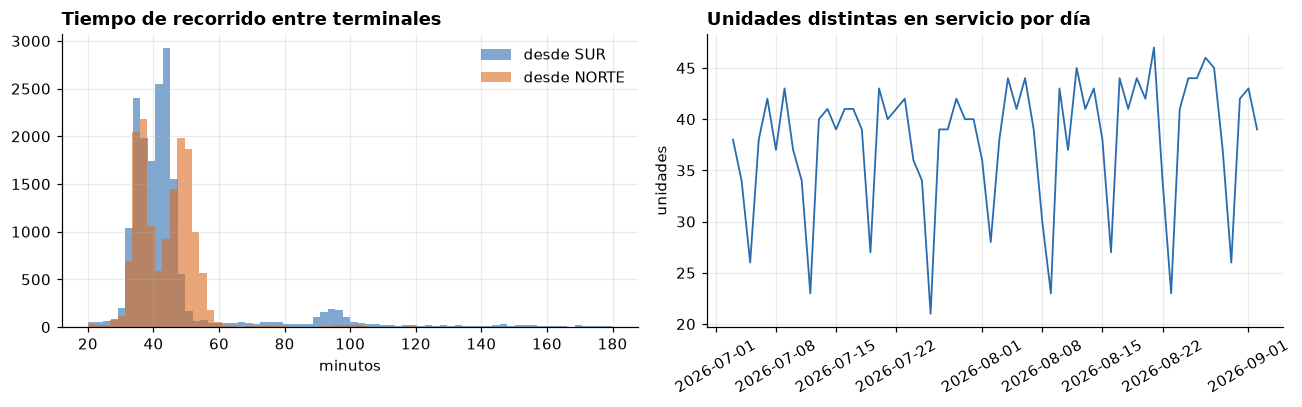

recorrido mediano : 42.3 min
p90               : 53.6 min
unidades/día      : mediana 40 · min 21 · máx 47


In [10]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 3.8))
for z, c in [("SUR", AZUL), ("NORTE", NARANJA)]:
    a1.hist(sal[sal.desde == z].recorrido_min, bins=70, alpha=.6, label=f"desde {z}", color=c)
a1.set_title("Tiempo de recorrido entre terminales", loc="left", weight="bold")
a1.set_xlabel("minutos"); a1.legend(frameon=False)

flota = sal.groupby("fecha").id_bus.nunique()
a2.plot(pd.to_datetime(flota.index), flota.values, color=AZUL, lw=1.2)
a2.set_title("Unidades distintas en servicio por día", loc="left", weight="bold")
a2.set_ylabel("unidades"); a2.tick_params(axis="x", rotation=30)
plt.tight_layout(); plt.show()

print(f"recorrido mediano : {sal.recorrido_min.median():.1f} min")
print(f"p90               : {sal.recorrido_min.quantile(.9):.1f} min")
print(f"unidades/día      : mediana {flota.median():.0f} · min {flota.min()} · máx {flota.max()}")

La cola larga a la derecha es congestión: el p90 se separa bastante de la mediana. Para el
modelo, el tiempo de vuelta **no** es constante y depende de la hora — hay que tratarlo como
variable de estado, no como parámetro fijo.

## 6. Oferta contra demanda

La gráfica que resume por qué el proyecto tiene sentido.

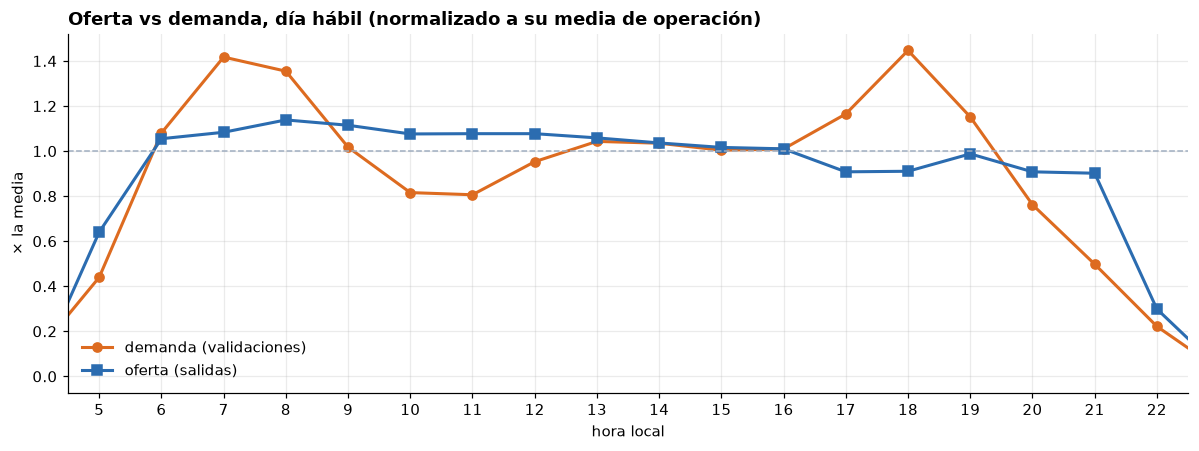

franja núcleo 06–20h
  demanda  pico   10,589 a las 18h · valle    5,578 a las 20h · razón 1.90
  oferta   pico     20.8 a las 08h · valle     16.6 a las 17h · razón 1.25
  correlación oferta–demanda: -0.027


In [11]:
dh = demand.demanda_por_hora()
dem = dh[~dh.finde.astype(bool)].set_index("hora")
dem_dia = (dem["validaciones"] / dem["dias"]).reindex(range(24)).fillna(0)
ofe = perfil["hábil"]


def norm(s):
    return s / s[s.index.isin(range(5, 22))].mean()


fig, ax = plt.subplots(figsize=(11, 4.2))
ax.plot(range(24), norm(dem_dia), marker="o", color=NARANJA, lw=2, label="demanda (validaciones)")
ax.plot(range(24), norm(ofe), marker="s", color=AZUL, lw=2, label="oferta (salidas)")
ax.axhline(1, color=GRIS, ls="--", lw=1)
ax.set_xlim(4.5, 22.5); ax.set_xticks(range(5, 23))
ax.set_title("Oferta vs demanda, día hábil (normalizado a su media de operación)",
             loc="left", weight="bold")
ax.set_xlabel("hora local"); ax.set_ylabel("× la media")
ax.legend(frameon=False); plt.tight_layout(); plt.show()

d_op, o_op = dem_dia.loc[CORE_H], ofe.loc[CORE_H]
print(f"franja núcleo {CORE_H[0]:02d}–{CORE_H[-1]:02d}h")
print(f"  demanda  pico {d_op.max():>8,.0f} a las {d_op.idxmax():02d}h · "
      f"valle {d_op.min():>8,.0f} a las {d_op.idxmin():02d}h · razón {d_op.max() / d_op.min():.2f}")
print(f"  oferta   pico {o_op.max():>8,.1f} a las {o_op.idxmax():02d}h · "
      f"valle {o_op.min():>8,.1f} a las {o_op.idxmin():02d}h · razón {o_op.max() / o_op.min():.2f}")
print(f"  correlación oferta–demanda: {np.corrcoef(d_op, o_op)[0, 1]:+.3f}")

In [12]:
# La correlación es sensible a dónde se corte la ventana. Vale la pena verlo explícito
# en vez de reportar un solo número que suena mejor de lo que es.
filas = []
for lo, hi in [(6, 20), (6, 21), (5, 21), (5, 22)]:
    o, d = ofe.loc[lo:hi], dem_dia.loc[lo:hi]
    filas.append({
        "ventana": f"{lo:02d}–{hi:02d}h",
        "razón oferta": round(o.max() / o.min(), 2),
        "razón demanda": round(d.max() / d.min(), 2),
        "correlación": round(np.corrcoef(o, d)[0, 1], 3),
    })
pd.DataFrame(filas)

,ventana,razón oferta,razón demanda,correlación
0,06–20h,1.25,1.90,-0.027
1,06–21h,1.26,2.91,0.217
2,05–21h,1.78,3.29,0.517
3,05–22h,3.81,6.52,0.704


Las dos curvas apenas se parecen. La demanda tiene picos gemelos claros a las 07 h y las
18 h; la oferta es una meseta que ni los acompaña ni los anticipa.

**Cuidado con la correlación.** La tabla de sensibilidad muestra que pasa de **−0.03** en la
franja núcleo a **+0.52** si se incluyen las horas de arranque y cierre. Esa correlación
alta es espuria: en los extremos ambas series suben y bajan juntas simplemente porque el
servicio abre y cierra, no porque el despacho siga a la demanda. El número honesto es el de
la franja núcleo, y ahí **no hay relación**.

**Esa brecha es el espacio de mejora del agente**: mover salidas del valle al pico, sin
cambiar el total de unidades, ya mejora ambos términos de la recompensa.

## 7. Huecos y siguientes pasos

**Lo que bloquea la función de recompensa.** No existe capacidad ni costo por unidad en
ninguna de las 303 columnas. Hay que pedir al cliente el mapeo `model`/`brand` → capacidad y
costo por vuelta. Mientras tanto, tratarlo como parámetro configurable.

**Lo que no se puede medir todavía.** Las validaciones dicen quién **sube**, no quién
**baja** ni cuánta gente **se quedó esperando**. La ocupación a bordo hay que estimarla con
un modelo de descenso, y la demanda insatisfecha no está observada en absoluto. Es una
limitación de fondo: sólo se ve la demanda *atendida*.

**Riesgo de atribución en T01.** Sus 3.14 M pings resuelven vía `id_oct`, pero esa ruta trae
`id_bus = 0`. Conviene validar contra la troncal antes de mezclarlas.

**Siguiente paso natural.** Materializar una tabla de vueltas —una fila por vuelta con hora
de salida, recorrido, unidad y validaciones asociadas— en Parquet, y sobre eso montar el
entorno de RL. La ruta ya está en `data/export/`.